## Model Evaluation & Decision Strategy

In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [2]:
import joblib
import numpy as np
import pandas as pd
from src.model import load_model
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import matplotlib.pyplot as plt

### Load Trained Model & Test Data

In [3]:
bundle = load_model('bundle.pkl')

model = bundle["model"]
X_test = bundle["X_test"]
y_test = bundle["y_test"]

In [4]:
y_pred = model.predict_proba(X_test)[:,1]

### ROC Curve & ROC-AUC Evaluation

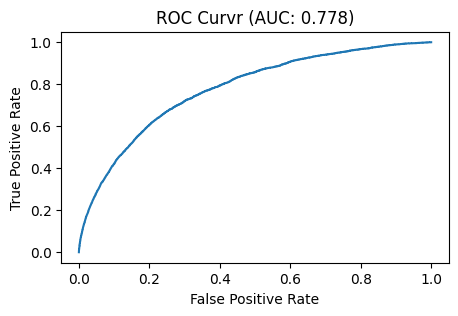

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,3))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curvr (AUC: {roc_auc:.3f})')
plt.show()

### Precision–Recall Curve Analysis (Imbalanced Focus)

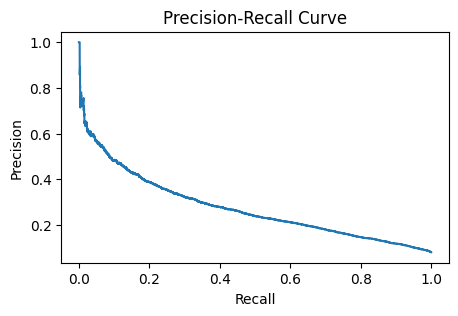

In [7]:
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure(figsize=(5,3))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

### Confusion Matrix at Default Threshold (0.5)

In [8]:
y_pd = (y_pred >= 0.5).astype(int)
confusion_matrix(y_test, y_pd)

array([[41274, 15264],
       [ 1533,  3432]])

### Threshold Sensitivity Analysis (0.3, 0.4, 0.5)

In [9]:
for t in [0.5, 0.4, 0.3]:
    y_pd = (y_pred >= t).astype(int)
    cm = confusion_matrix(y_test, y_pd)
    print(f'\nThreshold: {t}')
    print(cm)


Threshold: 0.5
[[41274 15264]
 [ 1533  3432]]

Threshold: 0.4
[[33487 23051]
 [  994  3971]]

Threshold: 0.3
[[24140 32398]
 [  544  4421]]


### F1-Score Based Threshold Optimization

In [10]:
best_f1 = 0
best_trshld=0

for t in np.linspace(0.1,0.9,50):
    y_pd = (y_pred>=t).astype(int)
    f1 = f1_score(y_test, y_pd)

    if f1>best_f1:
        best_f1 = f1
        best_trshld = t

print(f'Best Threshold: {best_trshld}')
print(f'Best F1: {best_f1}')

Best Threshold: 0.6551020408163265
Best F1: 0.33065170861318177


### Business Interpretation of Threshold Trade-Off

At threshold 0.5:
- False Negatives = 1533          
- Recall = ~69%

At threshold 0.3: 
- False Negatives = 544      
- Recall = ~89%

Lowering threshold significantly reduces missed positive cases, but increased false positive.    
If false negatives are expensive a lower threshold may be more appropriate.